In [1]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
x_train = pd.read_csv("data_train_x.csv")
y_train = pd.read_csv("data_train_y.csv")
x_test = pd.read_csv("data_test_x.csv")
y_test = pd.read_csv("data_test_y.csv")

print("训练集大小:", len(x_train))
print("外部验证集大小:", len(x_test))

训练集大小: 918
外部验证集大小: 234


In [3]:
import joblib
best_model = joblib.load('RandomForest_regression_model.pkl')
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

y_pred_test = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\n测试集性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



测试集性能:
均方误差 (MSE): 44.6036
均方根误差 (RMSE): 6.6786
平均绝对误差 (MAE): 4.2409
决定系数 (R²): 0.5648


In [4]:
y_pred_train = best_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print("\ntrain性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



train性能:
均方误差 (MSE): 4.0195
均方根误差 (RMSE): 2.0049
平均绝对误差 (MAE): 1.2597
决定系数 (R²): 0.9459


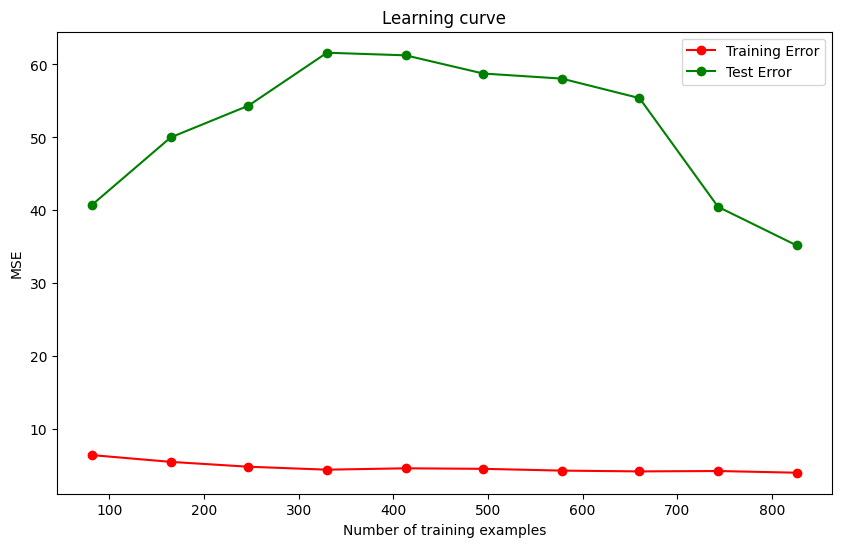

In [5]:
def plot_learning_curve(model, X, y):

    from sklearn.model_selection import learning_curve
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=10, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Error')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Error')
    plt.xlabel('Number of training examples')
    plt.ylabel('MSE')
    plt.title('Learning curve')
    plt.legend(loc='best')
    plt.show()

plot_learning_curve(best_model, x_train, y_train)

In [6]:
import shap
explainer = shap.Explainer(best_model, x_train)
shap_values = explainer(x_train)
shap.plots.beeswarm(shap_values)

 99%|===================| 905/918 [00:32<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 20.807530, while the model output was 20.604638. If this difference is acceptable you can set check_additivity=False to disable this check.

In [7]:
y_pred_train_pd = pd.DataFrame()
y_pred_train_pd['S(mg/g)_pred'] = y_pred_train
y_pred_train_pd

,S(mg/g)_pred
0,12.144982
1,12.941538
2,12.641663
3,13.818836
4,12.245217
...,...
913,7.229492
914,2.883036
915,1.909841
916,1.706118


In [8]:
y_pred_test_pd = pd.DataFrame()
y_pred_test_pd['S(mg/g)_pred'] = y_pred_test
y_pred_test_pd

,S(mg/g)_pred
0,17.585938
1,16.140994
2,16.464987
3,16.897192
4,15.292047
...,...
229,8.046317
230,3.317466
231,2.632259
232,2.532850


In [9]:
RF_train_result = x_train.join(y_train).join(y_pred_train_pd)
RF_train_result.to_csv('RF_train_result.csv')
RF_test_result = x_test.join(y_test).join(y_pred_test_pd)
RF_test_result.to_csv('RF_test_result.csv')